# Fine-tuning Mask2Former sur GT CoolPath (CVAT)

**Objectif :** adapter Mask2Former (pré-entraîné Cityscapes) aux frames GoPro/Nantes/piéton via les 25 frames annotées dans CVAT.

**Pipeline :**
1. Conversion masks CVAT RGB → indices Cityscapes 0..18 (background → 255 ignore)
2. Split train/val
3. Dataset MMSeg custom
4. Config de fine-tuning (LR bas, peu d'itérations, depuis checkpoint Cityscapes)
5. Entraînement
6. Comparaison avant/après sur les frames

**Note :** 25 images c'est peu. On fait du fine-tuning léger (pas un entraînement complet) : LR faible, peu d'itérations, pour spécialiser sans détruire les poids Cityscapes (catastrophic forgetting).

## 1. Environnement + chemins

In [1]:
import sys, torch
from pathlib import Path
import numpy as np
from PIL import Image
import shutil

print(f"PyTorch : {torch.__version__}")
print(f"GPU : {torch.cuda.get_device_name(0)}")
import mmseg
print(f"mmsegmentation : {mmseg.__version__}")

PROJECT_ROOT = Path("..").resolve()
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"

CVAT_DIR  = Path(r"C:\Users\youss\Downloads\coolpath_local\data\cvat_export")
FRAMES_SRC = PROJECT_ROOT / "data" / "outputs" / "video_4models" / "frames_to_annotate"

DATASET_DIR = PROJECT_ROOT / "data" / "coolpath_finetune"
WORK_DIR    = PROJECT_ROOT / "data" / "outputs" / "finetune_mask2former"
DATASET_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"CVAT export  : {CVAT_DIR}")
print(f"Frames source: {FRAMES_SRC}")
print(f"Dataset      : {DATASET_DIR}")


PyTorch : 2.1.0+cu118
GPU : NVIDIA GeForce RTX 2060
mmsegmentation : 1.2.2
CVAT export  : C:\Users\youss\Downloads\coolpath_local\data\cvat_export
Frames source: C:\Users\youss\Downloads\coolpath_local\data\outputs\video_4models\frames_to_annotate
Dataset      : C:\Users\youss\Downloads\coolpath_local\data\coolpath_finetune


## 2. Conversion masks CVAT RGB → indices Cityscapes

Le `labelmap.txt` donne couleur RGB → nom de classe. On mappe vers les **indices Cityscapes officiels** (road=0, sidewalk=1, ... bicycle=18). La classe CVAT `background` (0,0,0) → **255 (ignore)**.

In [2]:
# Ordre officiel Cityscapes 19 classes (l'index = la valeur dans le mask final)
CITYSCAPES_ORDER = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic_light",
    "traffic_sign", "vegetation", "terrain", "sky", "person", "rider",
    "car", "truck", "bus", "train", "motorcycle", "bicycle",
]
name_to_idx = {n: i for i, n in enumerate(CITYSCAPES_ORDER)}

# Parse labelmap.txt
labelmap = {}
for line in (CVAT_DIR / "labelmap.txt").read_text().splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue
    parts = line.split(":")
    name = parts[0]
    rgb = tuple(int(x) for x in parts[1].split(","))
    labelmap[rgb] = name

print("Correspondance couleur → classe → indice Cityscapes :")
color_to_classidx = {}
for rgb, name in labelmap.items():
    if name == "background":
        idx = 255
    else:
        idx = name_to_idx[name]
    color_to_classidx[rgb] = idx
    print(f"  RGB {str(rgb):<16s} {name:<15s} → {idx}")


Correspondance couleur → classe → indice Cityscapes :
  RGB (0, 0, 0)        background      → 255
  RGB (119, 11, 32)    bicycle         → 18
  RGB (70, 70, 70)     building        → 2
  RGB (0, 60, 100)     bus             → 15
  RGB (0, 0, 142)      car             → 13
  RGB (190, 153, 153)  fence           → 4
  RGB (0, 0, 230)      motorcycle      → 17
  RGB (220, 20, 60)    person          → 11
  RGB (153, 153, 153)  pole            → 5
  RGB (255, 0, 0)      rider           → 12
  RGB (128, 64, 128)   road            → 0
  RGB (244, 35, 232)   sidewalk        → 1
  RGB (70, 130, 180)   sky             → 10
  RGB (152, 251, 152)  terrain         → 9
  RGB (250, 170, 30)   traffic_light   → 6
  RGB (220, 220, 0)    traffic_sign    → 7
  RGB (0, 80, 100)     train           → 16
  RGB (0, 0, 70)       truck           → 14
  RGB (107, 142, 35)   vegetation      → 8
  RGB (102, 102, 156)  wall            → 3


In [3]:
# Conversion de tous les masks
IMG_OUT = DATASET_DIR / "images"
LBL_OUT = DATASET_DIR / "labels"
IMG_OUT.mkdir(parents=True, exist_ok=True)
LBL_OUT.mkdir(parents=True, exist_ok=True)

mask_files = sorted((CVAT_DIR / "SegmentationClass").glob("*.png"))
print(f"{len(mask_files)} masks à convertir\n")

converted = 0
for mp in mask_files:
    rgb_mask = np.array(Image.open(mp).convert("RGB"))
    h, w = rgb_mask.shape[:2]
    idx_mask = np.full((h, w), 255, dtype=np.uint8)  # défaut = ignore

    for color, cls_idx in color_to_classidx.items():
        match = np.all(rgb_mask == np.array(color), axis=-1)
        idx_mask[match] = cls_idx

    # Sauvegarde du label (indices)
    Image.fromarray(idx_mask).save(LBL_OUT / mp.name)

    # Copie de l'image correspondante (.jpg)
    img_src = FRAMES_SRC / (mp.stem + ".jpg")
    if img_src.exists():
        shutil.copy(img_src, IMG_OUT / (mp.stem + ".jpg"))
        converted += 1
    else:
        print(f"  ⚠ image manquante : {img_src.name}")

print(f"{converted} paires (image, label) prêtes dans {DATASET_DIR}")

# Vérification
sample = np.array(Image.open(sorted(LBL_OUT.glob('*.png'))[0]))
print(f"Exemple label : valeurs uniques = {np.unique(sample)}")


25 masks à convertir

25 paires (image, label) prêtes dans C:\Users\youss\Downloads\coolpath_local\data\coolpath_finetune
Exemple label : valeurs uniques = [  1   2   3   4   5   8  10  11  13 255]


## 3. Split train / val (80 / 20)

In [4]:
import random
random.seed(42)

all_stems = sorted([p.stem for p in IMG_OUT.glob("*.jpg")])
random.shuffle(all_stems)

n_val = max(2, int(0.2 * len(all_stems)))
val_stems = sorted(all_stems[:n_val])
train_stems = sorted(all_stems[n_val:])

(DATASET_DIR / "splits").mkdir(exist_ok=True)
(DATASET_DIR / "splits" / "train.txt").write_text("\n".join(train_stems))
(DATASET_DIR / "splits" / "val.txt").write_text("\n".join(val_stems))

print(f"Train : {len(train_stems)} images")
print(f"Val   : {len(val_stems)} images")
print(f"Val   : {val_stems}")


Train : 20 images
Val   : 5 images
Val   : ['frame_00032', 'frame_00047', 'frame_00051', 'frame_00070', 'frame_00074']


## 4. Config de fine-tuning

Fine-tuning **léger** depuis le checkpoint Cityscapes :
- LR très bas (`1e-5`) pour ne pas détruire les poids pré-entraînés
- Peu d'itérations (`2000`)
- `num_classes=19` (mêmes classes Cityscapes)
- Eval régulière sur le val set

In [5]:
m2f_base_cfg = CHECKPOINTS_DIR / "mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024.py"
m2f_ckpt = list(CHECKPOINTS_DIR.glob("mask2former_swin-b*.pth"))[0]

assert m2f_base_cfg.exists(), f"Config Mask2Former introuvable : {m2f_base_cfg}"
print(f"Config base : {m2f_base_cfg.name}")
print(f"Checkpoint  : {m2f_ckpt.name}")

finetune_cfg = WORK_DIR / "mask2former_coolpath_finetune.py"

cfg_content = f'''
_base_ = r"{m2f_base_cfg.as_posix()}"

# ---- Dataset custom CoolPath ----
dataset_type = "BaseSegDataset"
data_root = r"{DATASET_DIR.as_posix()}"

metainfo = dict(
    classes=(
        "road","sidewalk","building","wall","fence","pole","traffic_light",
        "traffic_sign","vegetation","terrain","sky","person","rider",
        "car","truck","bus","train","motorcycle","bicycle"
    ),
)

train_pipeline = [
    dict(type="LoadImageFromFile"),
    dict(type="LoadAnnotations"),
    dict(type="RandomResize", scale=(1920, 1080),
         ratio_range=(0.7, 1.3), keep_ratio=True),
    dict(type="RandomCrop", crop_size=(512, 1024), cat_max_ratio=0.9),
    dict(type="RandomFlip", prob=0.5),
    dict(type="PhotoMetricDistortion"),
    dict(type="PackSegInputs"),
]

test_pipeline = [
    dict(type="LoadImageFromFile"),
    dict(type="Resize", scale=(1920, 1080), keep_ratio=True),
    dict(type="LoadAnnotations"),
    dict(type="PackSegInputs"),
]

train_dataloader = dict(
    batch_size=1,
    num_workers=2,
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        data_prefix=dict(img_path="images", seg_map_path="labels"),
        img_suffix=".jpg",
        seg_map_suffix=".png",
        ann_file="splits/train.txt",
        metainfo=metainfo,
        pipeline=train_pipeline,
    ),
)

val_dataloader = dict(
    batch_size=1,
    num_workers=2,
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        data_prefix=dict(img_path="images", seg_map_path="labels"),
        img_suffix=".jpg",
        seg_map_suffix=".png",
        ann_file="splits/val.txt",
        metainfo=metainfo,
        pipeline=test_pipeline,
    ),
)
test_dataloader = val_dataloader

# ---- Charger depuis le checkpoint Cityscapes ----
load_from = r"{m2f_ckpt.as_posix()}"

# ---- Fine-tuning léger ----
optim_wrapper = dict(
    optimizer=dict(type="AdamW", lr=1e-5, weight_decay=0.05),
)
param_scheduler = [
    dict(type="PolyLR", eta_min=0, power=0.9, begin=0, end=2000, by_epoch=False),
]

train_cfg = dict(type="IterBasedTrainLoop", max_iters=2000, val_interval=250)
val_cfg = dict(type="ValLoop")
test_cfg = dict(type="TestLoop")

default_hooks = dict(
    checkpoint=dict(type="CheckpointHook", by_epoch=False,
                    interval=250, max_keep_ckpts=2, save_best="mIoU", save_last=True),
    logger=dict(type="LoggerHook", interval=20),
)

work_dir = r"{WORK_DIR.as_posix()}"
'''

finetune_cfg.write_text(cfg_content.strip(), encoding="utf-8")
print(f"\nConfig fine-tuning écrite : {finetune_cfg}")


Config base : mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024.py
Checkpoint  : mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024_20221203_045030-9a86a225.pth

Config fine-tuning écrite : C:\Users\youss\Downloads\coolpath_local\data\outputs\finetune_mask2former\mask2former_coolpath_finetune.py


## 5. Lancement de l'entraînement

⚠️ Sur RTX 2060 6 Go, batch_size=1, crop 512×1024. ~2000 itérations ≈ 30-60 min selon la machine. Le meilleur checkpoint (mIoU val) est sauvegardé automatiquement.

In [7]:
import subprocess

# Trouver le script train.py de mmseg
train_script = Path(mmseg.__file__).parent / ".mim" / "tools" / "train.py"
if not train_script.exists():
    # fallback : chercher dans l'install
    cands = list(Path(mmseg.__file__).parent.rglob("tools/train.py"))
    train_script = cands[0] if cands else None

assert train_script and train_script.exists(), "train.py de mmseg introuvable"
print(f"Script : {train_script}")


# AFTER
finetuning_ckpts = list(WORK_DIR.glob("iter_*.pth"))
last_ckpt_file = WORK_DIR / "last_checkpoint"
cmd = [sys.executable, str(train_script), str(finetune_cfg)]
if last_ckpt_file.exists():
    print(f"✅ Checkpoint précédent détecté, reprise automatique...")
    cmd += ["--resume"]
else:
    print("🆕 Pas de checkpoint précédent, entraînement from scratch.")
print(f"Commande : {' '.join(cmd)}\n")

# Lancement (sortie en direct)
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1)
for line in proc.stdout:
    print(line, end="")
proc.wait()
print(f"\n=== Entraînement terminé (code {proc.returncode}) ===")


Script : C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\mmseg\.mim\tools\train.py
🆕 Pas de checkpoint précédent, entraînement from scratch.
Commande : C:\Users\youss\miniconda3\envs\coolpath\python.exe C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\mmseg\.mim\tools\train.py C:\Users\youss\Downloads\coolpath_local\data\outputs\finetune_mask2former\mask2former_coolpath_finetune.py

05/19 14:57:02 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1259545844
    GPU 0: NVIDIA GeForce RTX 2060
    CUDA_HOME: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.0
    NVCC: Cuda compilation tools, release 13.0, V13.0.88
    GCC: n/a
    PyTorch: 2.1.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++

## 6. Comparaison avant / après fine-tuning

Checkpoint fine-tuné : best_mIoU_iter_750.pth
Loads checkpoint by local backend from path: C:\Users\youss\Downloads\coolpath_local\checkpoints\mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024_20221203_045030-9a86a225.pth
Loads checkpoint by local backend from path: C:\Users\youss\Downloads\coolpath_local\data\outputs\finetune_mask2former\best_mIoU_iter_750.pth


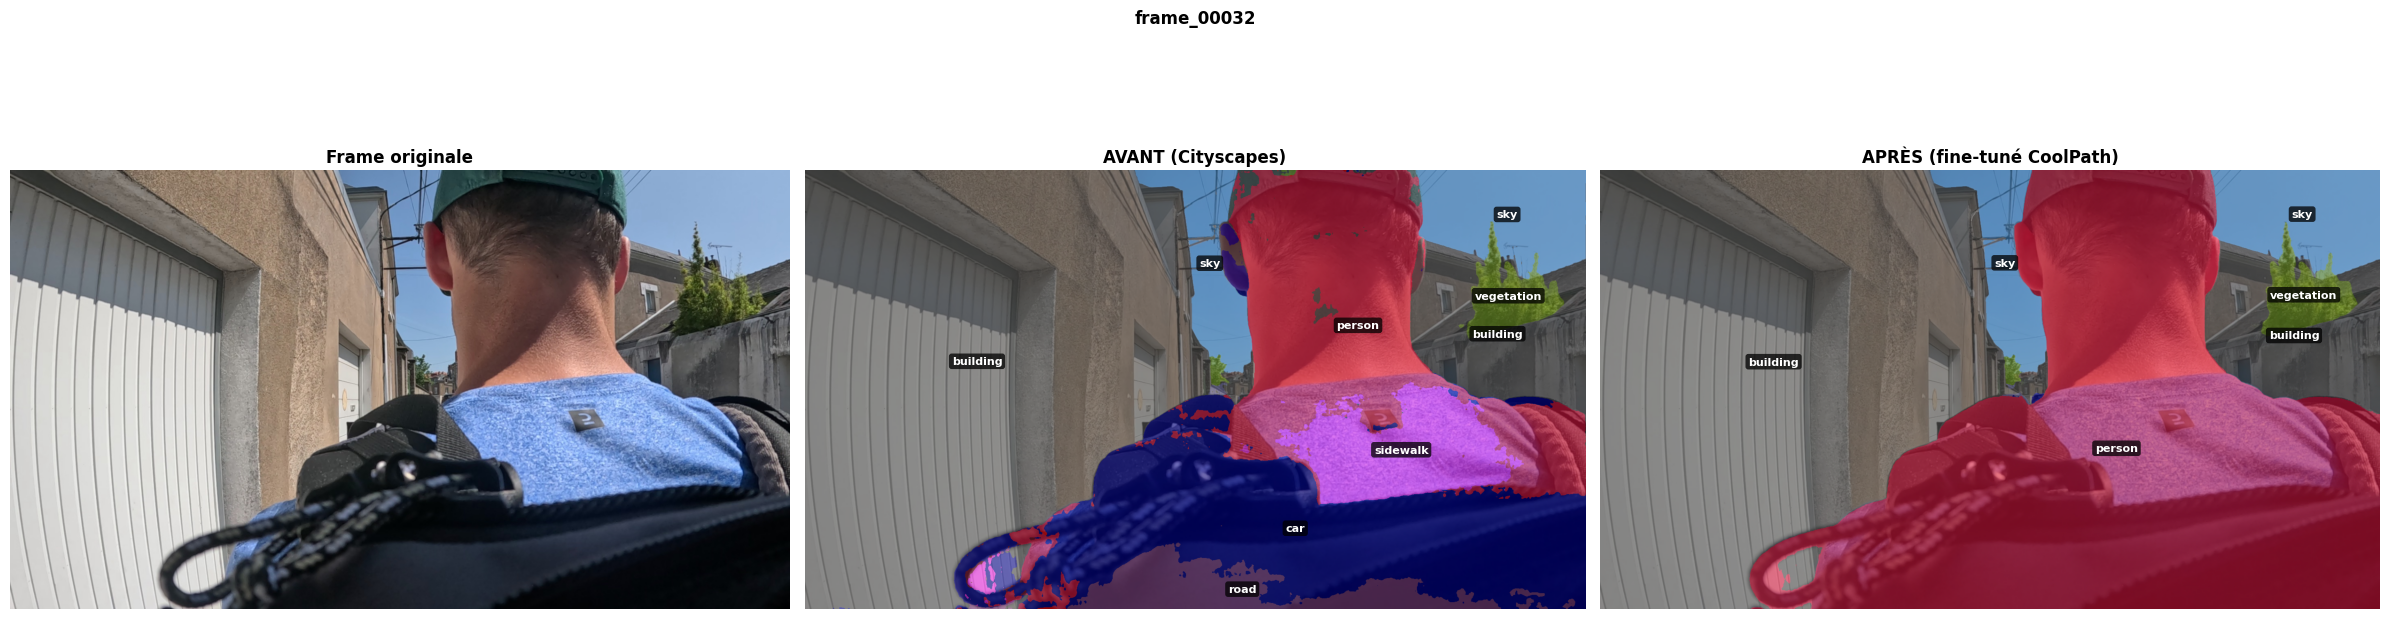

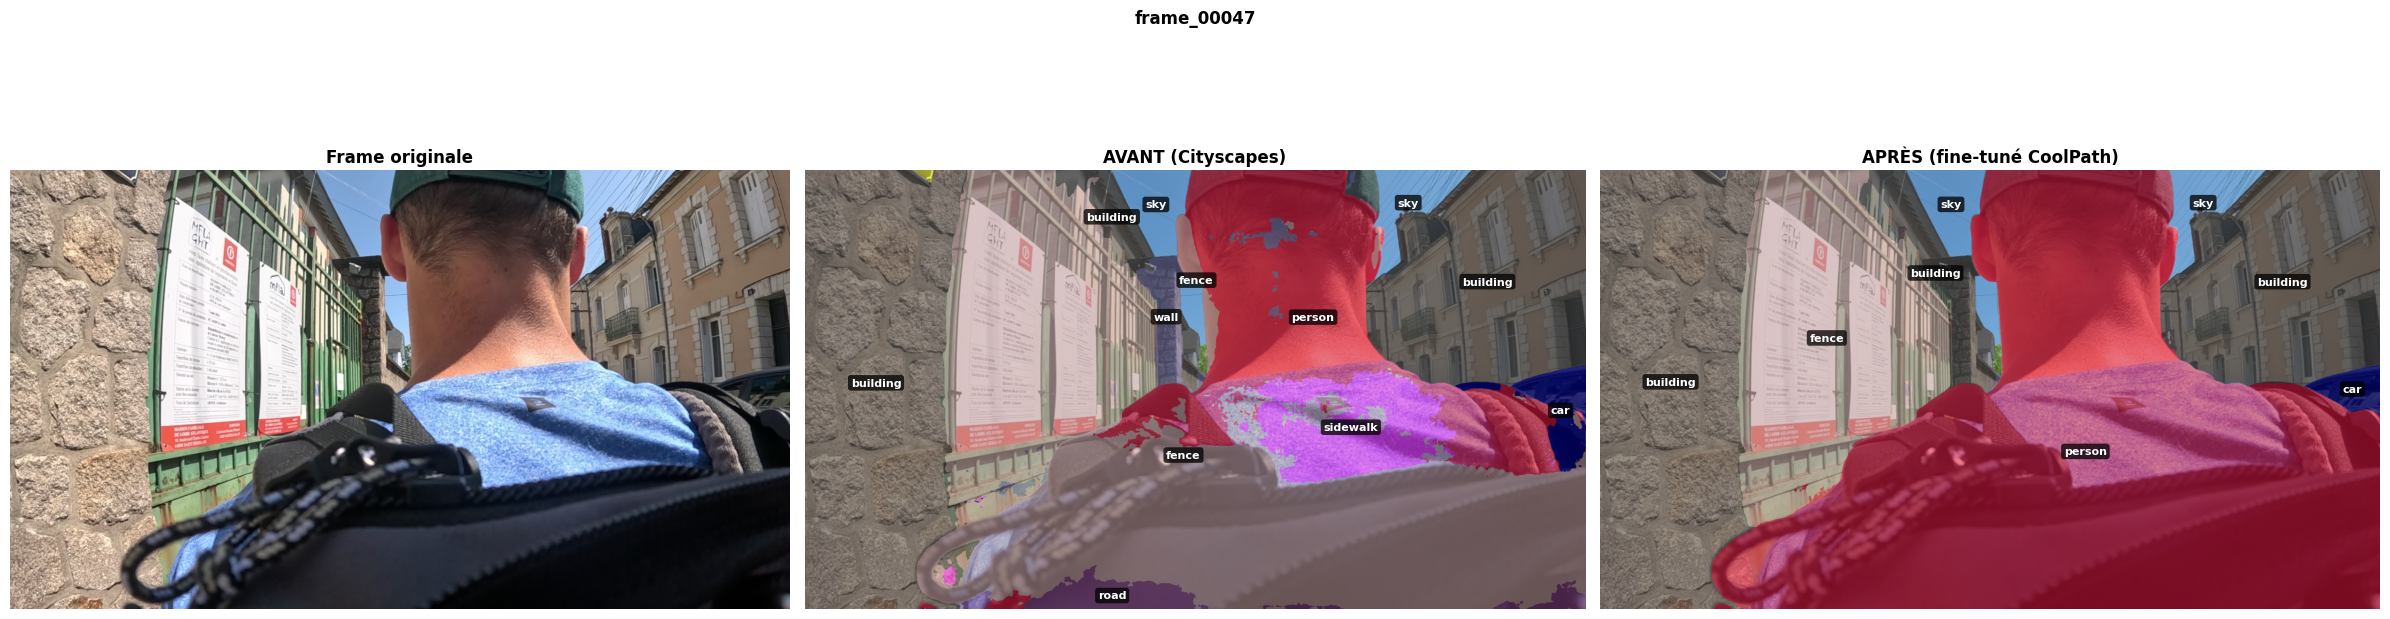

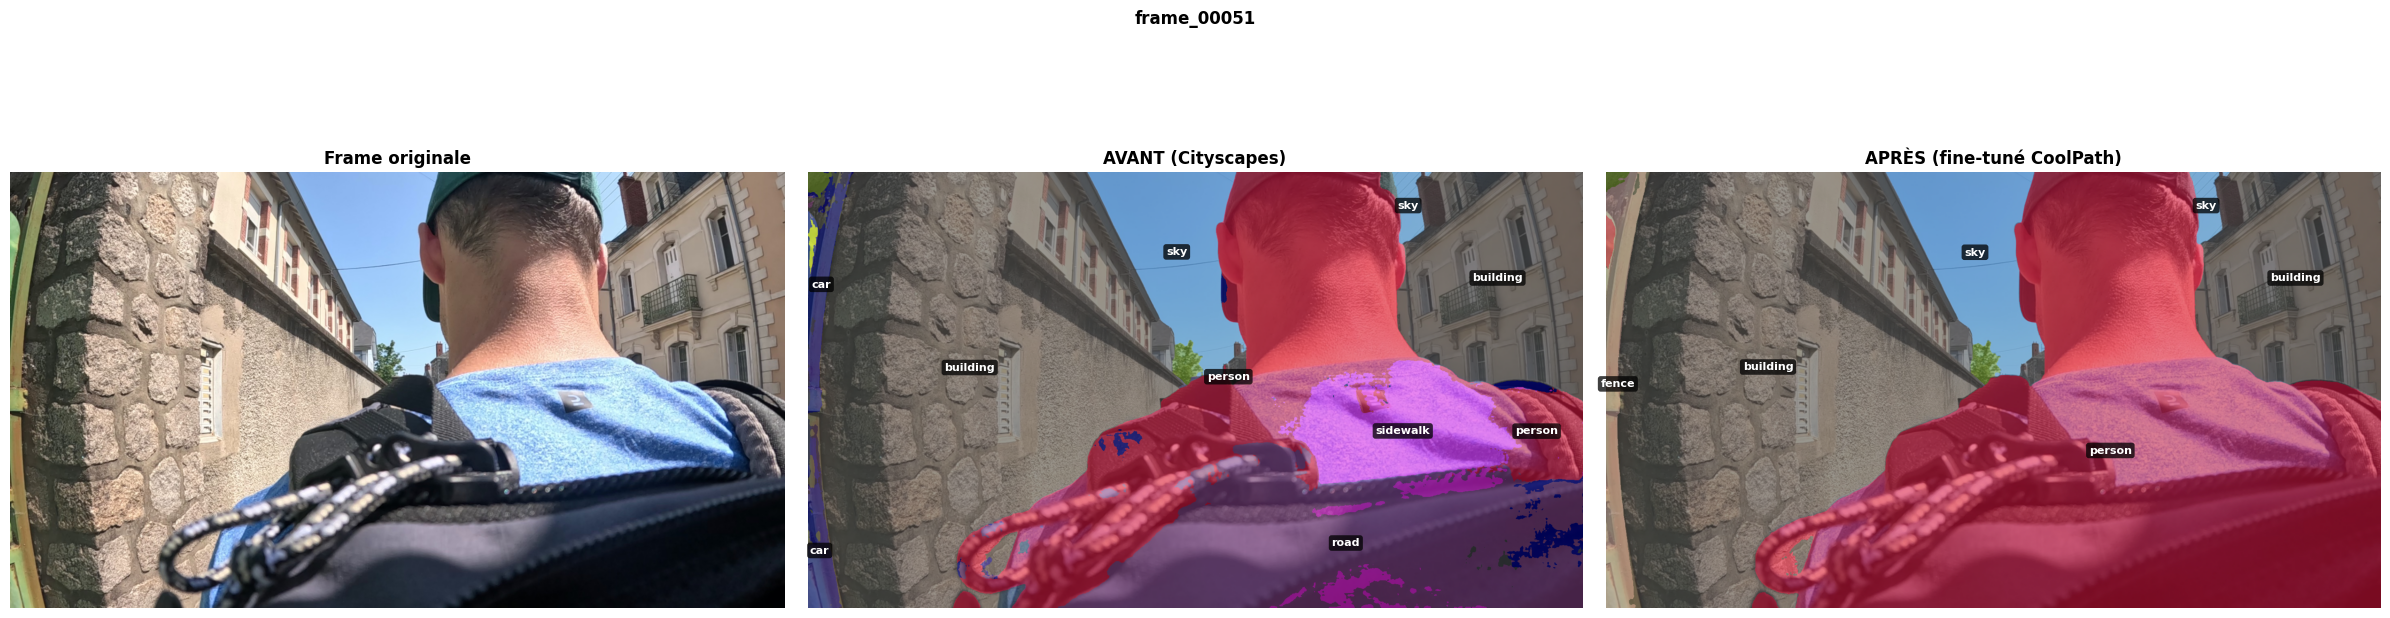

Comparaisons étiquetées sauvegardées dans C:\Users\youss\Downloads\coolpath_local\data\outputs\finetune_mask2former


In [8]:
from mmseg.apis import init_model, inference_model
from skimage.measure import label as cc_label, regionprops
import matplotlib.pyplot as plt
import cv2
import numpy as np

CITYSCAPES_PALETTE = np.array([
    [128,64,128],[244,35,232],[70,70,70],[102,102,156],[190,153,153],
    [153,153,153],[250,170,30],[220,220,0],[107,142,35],[152,251,152],
    [70,130,180],[220,20,60],[255,0,0],[0,0,142],[0,0,70],
    [0,60,100],[0,80,100],[0,0,230],[119,11,32],
], dtype=np.uint8)

CITYSCAPES_LABELS = [
    "road","sidewalk","building","wall","fence","pole","traffic_light",
    "traffic_sign","vegetation","terrain","sky","person","rider",
    "car","truck","bus","train","motorcycle","bicycle",
]


def colorize(m):
    out = np.zeros((*m.shape, 3), np.uint8)
    v = m < 19
    out[v] = CITYSCAPES_PALETTE[m[v]]
    return out


def draw_overlay_labeled(ax, img_rgb, mask, title, alpha=0.55, min_area_frac=0.004):
    """Masque superposé sur l'image + étiquette de classe au centre de chaque segment."""
    blended = ((1 - alpha) * img_rgb + alpha * colorize(mask)).astype(np.uint8)
    ax.imshow(blended)

    h, w = mask.shape
    min_area = int(min_area_frac * h * w)
    for cid in np.unique(mask):
        if cid >= 19:
            continue
        lbl = cc_label((mask == cid).astype(np.uint8))
        for reg in regionprops(lbl):
            if reg.area >= min_area:
                cy, cx = reg.centroid
                ax.text(cx, cy, CITYSCAPES_LABELS[cid], ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.25", facecolor="black",
                                  alpha=0.75, edgecolor="none"))
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.axis("off")


# Meilleur checkpoint fine-tuné
best_ckpts = sorted(WORK_DIR.glob("best_mIoU_*.pth"))
assert best_ckpts, "Pas de checkpoint best_mIoU trouvé"
best_ckpt = best_ckpts[-1]
print(f"Checkpoint fine-tuné : {best_ckpt.name}")

model_before = init_model(str(m2f_base_cfg), str(m2f_ckpt), device="cuda:0")
model_after  = init_model(str(finetune_cfg), str(best_ckpt), device="cuda:0")

test_stems = val_stems[:3]
for stem in test_stems:
    img_bgr = cv2.imread(str(IMG_OUT / f"{stem}.jpg"))
    h, w = img_bgr.shape[:2]
    if h > 1024:
        s = 1024 / h
        img_bgr = cv2.resize(img_bgr, (int(w * s), 1024))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pred_b = inference_model(model_before, img_bgr).pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
    pred_a = inference_model(model_after,  img_bgr).pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)

    fig, ax = plt.subplots(1, 3, figsize=(24, 7))
    ax[0].imshow(img_rgb); ax[0].set_title("Frame originale", fontweight="bold", fontsize=12); ax[0].axis("off")
    draw_overlay_labeled(ax[1], img_rgb, pred_b, "AVANT (Cityscapes)")
    draw_overlay_labeled(ax[2], img_rgb, pred_a, "APRÈS (fine-tuné CoolPath)")

    plt.suptitle(stem, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(WORK_DIR / f"compare_labeled_{stem}.png", dpi=100, bbox_inches="tight")
    plt.show()

del model_before, model_after
torch.cuda.empty_cache()
print(f"Comparaisons étiquetées sauvegardées dans {WORK_DIR}")

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# TEST FINAL : modèle fine-tuné sur les 152 frames de la vidéo GoPro
# Inférence sur TOUTES les frames, visualisations sur 20 frames aléatoires
# ════════════════════════════════════════════════════════════════════════════
import time
import random

FRAMES_VIDEO = PROJECT_ROOT / "data" / "video_frames"

INFERENCE_DIR = WORK_DIR / "video_inference"
MASKS_DIR     = INFERENCE_DIR / "masks_indices"
OVERLAY_DIR   = INFERENCE_DIR / "overlays_labeled"
INFERENCE_DIR.mkdir(parents=True, exist_ok=True)
MASKS_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

best_ckpts = sorted(WORK_DIR.glob("best_mIoU_*.pth"))
best_ckpt = best_ckpts[-1]
print(f"Checkpoint utilisé : {best_ckpt.name}\n")

model_ft = init_model(str(finetune_cfg), str(best_ckpt), device="cuda:0")

frame_files = sorted(FRAMES_VIDEO.glob("frame_*.jpg"))
print(f"{len(frame_files)} frames à traiter\n")

# Sélection aléatoire de 20 frames pour la visualisation
random.seed(42)
viz_set = set(random.sample([fp.name for fp in frame_files], min(20, len(frame_files))))
print(f"20 frames aléatoires sélectionnées pour visualisation\n")

class_counts_total = np.zeros(19, dtype=np.int64)
times = []
t_start = time.perf_counter()

for i, fp in enumerate(frame_files, 1):
    img_bgr = cv2.imread(str(fp))
    h, w = img_bgr.shape[:2]
    if h > 1024:
        s = 1024 / h
        img_bgr = cv2.resize(img_bgr, (int(w * s), 1024))

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    pred = inference_model(model_ft, img_bgr).pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
    torch.cuda.synchronize()
    times.append(time.perf_counter() - t0)

    # Toujours sauvegarder le masque d'indices (pour les indicateurs)
    cv2.imwrite(str(MASKS_DIR / f"{fp.stem}.png"), pred)

    # Visualisation uniquement pour les 20 frames sélectionnées
    if fp.name in viz_set:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(figsize=(14, 8))
        draw_overlay_labeled(ax, img_rgb, pred, f"{fp.name} — modèle fine-tuné CoolPath",
                             alpha=0.55, min_area_frac=0.004)
        plt.tight_layout()
        plt.savefig(OVERLAY_DIR / f"{fp.stem}.png", dpi=90, bbox_inches="tight")
        plt.close()

    class_counts_total += np.bincount(pred.ravel(), minlength=19)[:19].astype(np.int64)

    if i % 20 == 0 or i == len(frame_files):
        el = time.perf_counter() - t_start
        eta = el / i * (len(frame_files) - i)
        print(f"  [{i:>3}/{len(frame_files)}]  avg={el/i*1000:5.0f}ms/frame  ETA={eta:4.0f}s")

del model_ft
torch.cuda.empty_cache()

print(f"\n=== Inférence terminée ===")
print(f"Temps total              : {time.perf_counter() - t_start:.0f}s")
print(f"Temps moyen              : {np.mean(times)*1000:.0f} ms/frame")
print(f"FPS                      : {1.0/np.mean(times):.2f}")
print(f"\nMasques (toutes 152)     : {MASKS_DIR}")
print(f"Visualisations (20)      : {OVERLAY_DIR}")

Checkpoint utilisé : best_mIoU_iter_750.pth

Loads checkpoint by local backend from path: C:\Users\youss\Downloads\coolpath_local\data\outputs\finetune_mask2former\best_mIoU_iter_750.pth
153 frames à traiter

20 frames aléatoires sélectionnées pour visualisation

  [ 20/153]  avg=22422ms/frame  ETA=2982s
  [ 40/153]  avg=20474ms/frame  ETA=2314s
  [ 60/153]  avg=19593ms/frame  ETA=1822s
  [ 80/153]  avg=19214ms/frame  ETA=1403s
  [100/153]  avg=19389ms/frame  ETA=1028s
  [120/153]  avg=19832ms/frame  ETA= 654s
  [140/153]  avg=19786ms/frame  ETA= 257s
  [153/153]  avg=19660ms/frame  ETA=   0s

=== Inférence terminée ===
Temps total              : 3008s
Temps moyen              : 19519 ms/frame
FPS                      : 0.05

Masques (toutes 152)     : C:\Users\youss\Downloads\coolpath_local\data\outputs\finetune_mask2former\video_inference\masks_indices
Visualisations (20)      : C:\Users\youss\Downloads\coolpath_local\data\outputs\finetune_mask2former\video_inference\overlays_labeled